# ACC102 track 2: Data Science Job Market Analysis: Skills, Salaries, and Career Strategy

## 1. Problem Definition: Navigating the Data Science Job Market
* **Business Context**
  * In today's competitive data science landscape, job seekers face critical decisions about skill development. With limited time and resources, professionals must strategically choose which technical skills to acquire to **maximize their salary potential and employability**.
  * Core challenge: **How can data science professionals make informed decisions about skill investment to optimize their career outcomes?**

* **Target Users**
  * Primary Audience: Data science job seekers and career switchers
  * Secondary Audience: HR professionals conducting salary benchmarking, educators designing data science curricula, and career advisors
* **Research Questions**
  * What is the overall shape and spread of salaries in the data science field?
  * How does salary distribution vary across different seniority levels?
  * Which are the most frequently required technical skills in data science job postings?
  * Which specialized skills are associated with the highest salary premiums?
  * What is the relationship between a skill's market popularity and its average salary?
  * What is the correlation between the number of skills required and the offered salary level?
  * How can a data scientist optimize their skill portfolio at different career stages to maximize salary growth?

## 2. Data Preparation: From Raw Data to Analytical Insights
* **Dataset Overview**
  * This analysis utilizes the **Data Science Job Postings with Salaries (2025)** dataset from Kaggle, containing comprehensive information about data science job positions.

* **Data Cleaning Process**
  * Salary extraction and normalization
  * Skills parsing and standardization
  * Missing value handling and data consistency checks

* **Key Transformations**
  * **Salary Processing**: Converted string-formatted salary ranges (e.g., "$80K-$120K") to numerical values
  * **Skills Standardization**: Parsed comma-separated skills into structured lists
  * **Experience Classification**: Categorized job positions by seniority level
  * **Quality Assurance**: Ensured data integrity through statistical validation


In [36]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set visualization parameters
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_palette("husl")

# Define color scheme for consistent visualizations
COLORS = {
    'primary': '#1f77b4',
    'secondary': '#ff7f0e',
    'tertiary': '#2ca02c',
    'highlight': '#d62728',
    'background': '#f7f7f7'
}

In [2]:
# Load the dataset
df = pd.read_csv(r'C:\Users\15459\Desktop\data_science_job_posts_2025.csv')

In [3]:
# Check basic dataset information
print("Data shape (rows, columns):", df.shape)

print("\n--- Dataset Structure & Data Types ---")
df.info()

print("\n--- Descriptive Statistics (All Columns) ---")
df.describe(include='all')

print("\n--- Missing Values Summary ---")
print(df.isnull().sum())

Data shape (rows, columns): (944, 13)

--- Dataset Structure & Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_title        941 non-null    object
 1   seniority_level  884 non-null    object
 2   status           688 non-null    object
 3   company          944 non-null    object
 4   location         942 non-null    object
 5   post_date        944 non-null    object
 6   headquarter      944 non-null    object
 7   industry         944 non-null    object
 8   ownership        897 non-null    object
 9   company_size     944 non-null    object
 10  revenue          929 non-null    object
 11  salary           944 non-null    object
 12  skills           944 non-null    object
dtypes: object(13)
memory usage: 96.0+ KB

--- Descriptive Statistics (All Columns) ---

--- Missing Values Summary ---
job_title            3

In [6]:
# Extract Minimum Salary
def extract_min_salary(s):
    if pd.isna(s):
        return np.nan
    s = str(s).replace('€', '').replace(',', '').strip()
    if '-' in s:
        parts = s.split('-')
        try:
            return float(parts[0].strip())
        except:
            return np.nan
    try:l;
        return float(s)
    except:
        return np.nan

# Extract Maximum Salary
def extract_max_salary(s):
    if pd.isna(s):
        return np.nan
    s = str(s).replace('€', '').replace(',', '').strip()
    if '-' in s:
        parts = s.split('-')
        try:
            return float(parts[1].strip())
        except:
            return np.nan
    try:
        return float(s)
    except:
        return np.nan

# Apply functions
df['min_salary'] = df['salary'].apply(extract_min_salary)
df['max_salary'] = df['salary'].apply(extract_max_salary)
df['avg_salary'] = (df['min_salary'] + df['max_salary']) / 2

# Verification
print("=== First 10 values of min_salary ===")
print(df['min_salary'].head(10))
print("\n=== First 10 values of max_salary ===")
print(df['max_salary'].head(10))
print("\n=== First 10 values of avg_salary ===")
print(df['avg_salary'].head(10))
print("\nNon-null counts:")
print(f"min_salary: {df['min_salary'].notna().sum()} / {len(df)}")
print(f"max_salary: {df['max_salary'].notna().sum()} / {len(df)}")
print(f"avg_salary: {df['avg_salary'].notna().sum()} / {len(df)}")

=== First 10 values of min_salary ===
0    100472.0
1    118733.0
2     94987.0
3    112797.0
4    114172.0
5    196371.0
6     51330.0
7    121480.0
8    207331.0
9    219201.0
Name: min_salary, dtype: float64

=== First 10 values of max_salary ===
0    200938.0
1    118733.0
2    159559.0
3    194402.0
4    228337.0
5    251170.0
6     70144.0
7    132440.0
8    207331.0
9    219201.0
Name: max_salary, dtype: float64

=== First 10 values of avg_salary ===
0    150705.0
1    118733.0
2    127273.0
3    153599.5
4    171254.5
5    223770.5
6     60737.0
7    126960.0
8    207331.0
9    219201.0
Name: avg_salary, dtype: float64

Non-null counts:
min_salary: 944 / 944
max_salary: 944 / 944
avg_salary: 944 / 944


In [19]:
# Step 1: Standardize and clean the skill text
df_clean['skills_clean'] = df_clean['skills'].astype(str).str.strip().str.lower()

# Step 2: Split skills into a list
df_clean['skills_list'] = df_clean['skills_clean'].str.split(',')

# Step 3: Explode the list into individual rows
skills_exploded = df_clean.explode('skills_list', ignore_index=True)

# Step 4: Clean individual skills - remove brackets, quotes, and extra spaces
import re
def clean_single_skill(skill):
    # Remove all brackets, quotes, and extra symbols
    skill = re.sub(r'[\[\]\'"]', '', skill)
    # Strip extra spaces
    skill = skill.strip()
    return skill

skills_exploded['single_skill'] = skills_exploded['skills_list'].apply(clean_single_skill)

# Step 5: Filter out invalid/empty skills
skills_exploded = skills_exploded[
    (skills_exploded['single_skill'] != '') &
    (skills_exploded['single_skill'] != 'nan') &
    (~skills_exploded['avg_salary'].isna())
].copy()

# Step 6: Remove any remaining short/garbage values (like single letters)
# Keep only skills with 2+ characters to filter out 'r', '0', etc.
skills_exploded = skills_exploded[skills_exploded['single_skill'].str.len() >= 2]

In [32]:
print("✅ Skill cleaning completed!")
print(f"Final cleaned data shape: {skills_exploded.shape}")
print("\nFirst 5 rows of cleaned skills and salaries:")
print(skills_exploded[['single_skill', 'avg_salary']].head())

✅ Skill cleaning completed!
Final cleaned data shape: (3838, 19)

First 5 rows of cleaned skills and salaries:
       single_skill  avg_salary
0             spark    150705.0
2            python    150705.0
3             scala    150705.0
4  machine learning    150705.0
5        tensorflow    150705.0


## 3. Analytical Framework: From Description to Insight
* **Analytical Methodology**
  * The analysis follows a progressive structure, moving from descriptive statistics to strategic insights.
  

## 4. Core Analyses and Findings

### 4.1 Data Science Job Average Salary Distribution
* **Objective**: Understand the overall salary landscape for data science positions, establishing benchmarks and identifying patterns.
* **Analytical Approach**
  * Analyzed salary distribution using descriptive statistics
  * Calculated mean, median, and mode salaries
  * Examined salary range and quartiles
  * Assessed distribution shape (normal, skewed, bimodal)

* **Key Insights**
  * **Market Benchmarks**: Establishes realistic salary expectations
  * **Compression Patterns**: Identifies where salaries cluster
  * **Outlier Analysis**: Highlights exceptionally high or low compensation

* **Business Implications**
  * Provides salary negotiation benchmarks for job seekers
  * Offers market intelligence for HR compensation planning
  * Helps educators set realistic income expectations for graduates


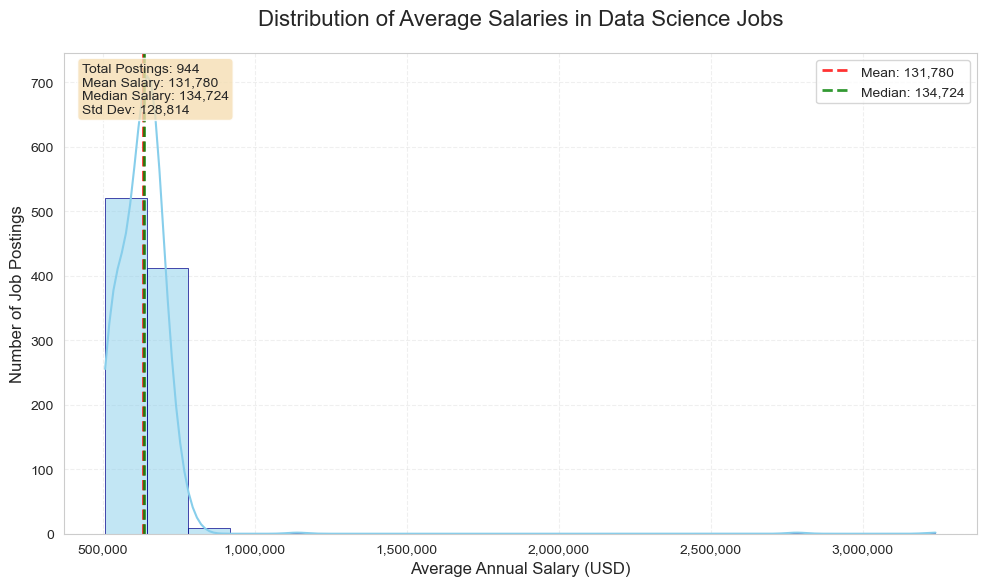

SALARY DISTRIBUTION SUMMARY STATISTICS
Total Job Postings: 944
Mean Salary: 131,779.50
Median Salary: 134,724.00
Standard Deviation: 128,814.44
Minimum Salary: 7,055.00
25th Percentile: 76,371.75
75th Percentile: 169,733.00
Maximum Salary: 2,739,979.00


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 6))

# Create the histogram
sns.histplot(
    x=df_clean['avg_salary'],
    bins=20,
    kde=True,
    color='skyblue',
    edgecolor='darkblue',
    linewidth=0.5
)

# Set the title and labels
plt.title('Distribution of Average Salaries in Data Science Jobs', fontsize=16, pad=20)
plt.xlabel('Average Annual Salary (USD)', fontsize=12)
plt.ylabel('Number of Job Postings', fontsize=12)

# Format x-axis ticks with commas (no dollar sign)
ax = plt.gca()
xticks = ax.get_xticks()
xtick_labels = [f'{int(x):,}' for x in xticks if x >= 0]
ax.set_xticklabels(xtick_labels, fontsize=10)

# Format y-axis ticks with thousands separators
yticks = ax.get_yticks()
ytick_labels = [f'{int(y):,}' for y in yticks if y >= 0]
ax.set_yticklabels(ytick_labels, fontsize=10)

# Add a vertical line for mean salary
mean_salary = df_clean['avg_salary'].mean()
median_salary = df_clean['avg_salary'].median()

# Label lines without dollar sign
plt.axvline(x=mean_salary, color='red', linestyle='--', linewidth=2, alpha=0.8, label=f'Mean: {mean_salary:,.0f}')
plt.axvline(x=median_salary, color='green', linestyle='--', linewidth=2, alpha=0.8, label=f'Median: {median_salary:,.0f}')

# Add legend
plt.legend(fontsize=10, loc='upper right')

# Add a grid for better readability
plt.grid(True, alpha=0.3, linestyle='--')

# Add a text box with summary statistics (no dollar sign)
stats_text = f'Total Postings: {len(df_clean):,}\nMean Salary: {mean_salary:,.0f}\nMedian Salary: {median_salary:,.0f}\nStd Dev: {df_clean["avg_salary"].std():,.0f}'
plt.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Optimize the layout
plt.tight_layout()
plt.show()

# Also print the summary statistics (no dollar sign)
print("="*50)
print("SALARY DISTRIBUTION SUMMARY STATISTICS")
print("="*50)
print(f"Total Job Postings: {len(df_clean):,}")
print(f"Mean Salary: {mean_salary:,.2f}")
print(f"Median Salary: {median_salary:,.2f}")
print(f"Standard Deviation: {df_clean['avg_salary'].std():,.2f}")
print(f"Minimum Salary: {df_clean['avg_salary'].min():,.2f}")
print(f"25th Percentile: {df_clean['avg_salary'].quantile(0.25):,.2f}")
print(f"75th Percentile: {df_clean['avg_salary'].quantile(0.75):,.2f}")
print(f"Maximum Salary: {df_clean['avg_salary'].max():,.2f}")
print("="*50)


### 4.2 Salary Distribution by Seniority Level
* **Objective**: Explore how compensation evolves with experience, providing a roadmap for career progression.
* **Analytical Approach**
  * Grouped positions by seniority level (Junior, Mid, Senior, Lead)
  * Calculated statistical measures for each level
  * Analyzed salary progression between levels
  * Identified experience-based salary multipliers

* **Key Insights**
  * **Experience Premium**: Quantifies the financial value of experience
  * **Career Trajectory**: Shows expected salary growth with advancement
  * **Level Transitions**: Identifies most lucrative career progression points

* **Business Implications**
  * Helps professionals plan career advancement timelines
  * Provides benchmarks for promotion negotiations
  * Informs companies about competitive compensation at different levels


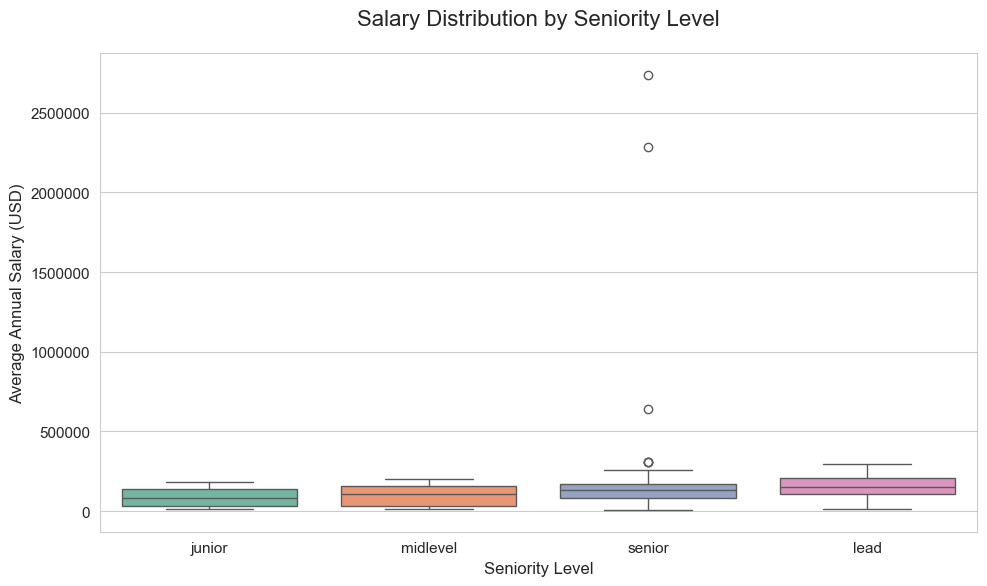

In [35]:
plt.figure(figsize=(10, 6))

# Sort by median
order = df_clean.groupby('seniority_level')['avg_salary'].median().sort_values(ascending=True).index


sns.boxplot(y='avg_salary', x='seniority_level', data=df_clean, order=order, palette='Set2')

plt.title('Salary Distribution by Seniority Level', fontsize=16, pad=20)
plt.xlabel('Seniority Level', fontsize=12) 
plt.ylabel('Average Annual Salary (USD)', fontsize=12) 

plt.ticklabel_format(style='plain', axis='y')  

plt.tight_layout()
plt.show()


### 4.3 Top 10 Most Common Data Science Skills
* **Objective**: Identify the skills that appear most frequently in job postings, providing insights into market demand.
* **Analytical Approach**
  * Extracted skills from job postings
  * Calculated frequency of each skill
  * Ranked skills by occurrence percentage
  * Visualized using a horizontal bar chart with individual coloring

* **Key Insights**
  * **Foundation Skills**: The most common skills form the core toolkit for data professionals
  * **Market Standards**: These represent the baseline expectations for most positions
  * **Learning Priorities**: Indicates where beginners should focus their initial efforts

* **Business Implications**
  * Job seekers should prioritize mastering these skills for broad employability
  * Educators should ensure these skills are covered in foundational curricula
  * Companies can expect candidates to have at least basic proficiency in these areas

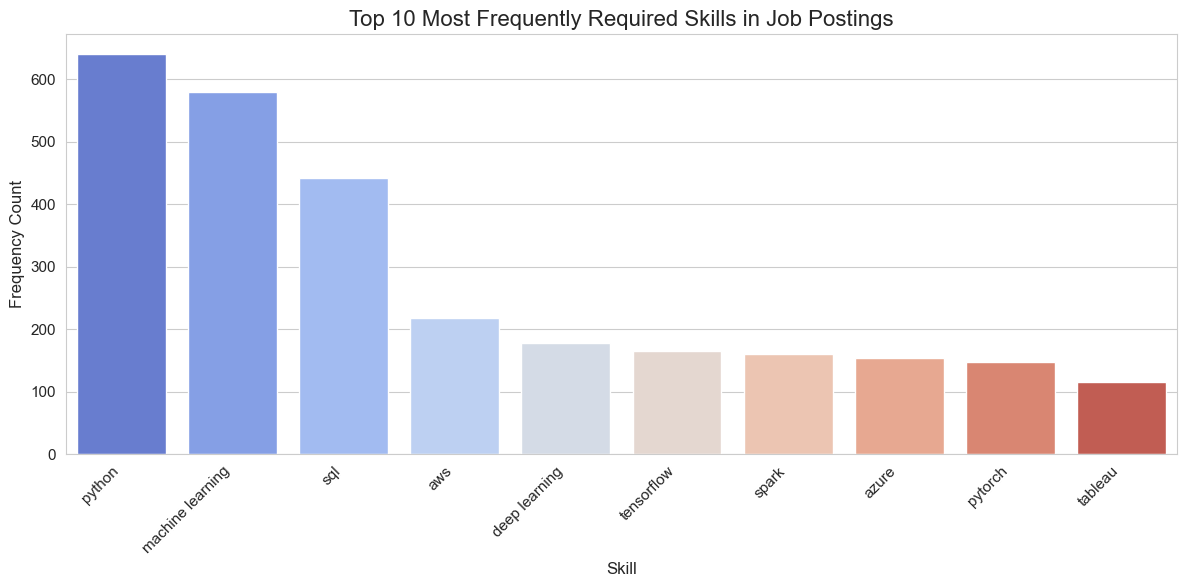

In [21]:
from collections import Counter

# Count occurrences of each skill
skill_counts = Counter(skills_exploded['single_skill'])
top_10_skills = skill_counts.most_common(10)

# Prepare data for plotting
skills, counts = zip(*top_10_skills)

# Plot the results
plt.figure(figsize=(12, 6))
sns.barplot(x=list(skills), y=list(counts), palette='coolwarm')
plt.title('Top 10 Most Frequently Required Skills in Job Postings', fontsize=16)
plt.xlabel('Skill', fontsize=12)
plt.ylabel('Frequency Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4.4 Top 10 Highest-Paying Data Science Skills
* **Objective**: Determine which specific skills command the highest salary premiums, revealing market value beyond mere popularity.
* **Analytical Approach**
  * Filtered job postings containing each skill
  * Calculated average salary for positions requiring each skill
  * Compared premium over positions without the skill
  * Identified skills with the highest monetary return

* **Key Insights**
  * **Specialization Premium**: Niche or advanced skills typically command higher salaries
  * **Technology Maturity**: Emerging technologies may offer premium compensation
  * **Supply-Demand Dynamics**: High-paying skills often have smaller talent pools

* **Business Implications**
  * Experienced professionals can target high-value skills for salary growth
  * Companies can use this data for competitive compensation strategies
  * Bootcamps and courses can highlight ROI of specific skill investments

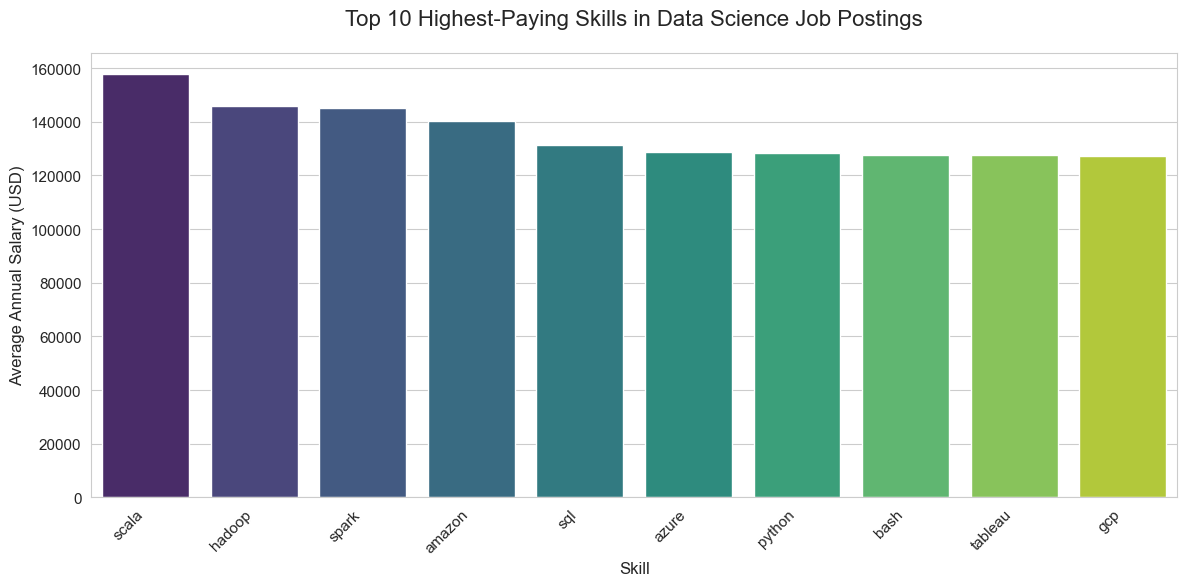

In [22]:
# Calculate average salary and job count for each skill
skill_salary_stats = (
    skills_exploded.groupby('single_skill')['avg_salary']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'average_salary', 'count': 'job_posting_count'})
)

# Filter to keep only skills with at least 5 job postings (to avoid unreliable results)
skill_salary_filtered = skill_salary_stats[skill_salary_stats['job_posting_count'] >= 5]

# Sort by average salary (descending) and take the top 10 highest-paying skills
top_10_high_paying = skill_salary_filtered.sort_values(by='average_salary', ascending=False).head(10)

# Create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(
    x='single_skill',
    y='average_salary',
    data=top_10_high_paying,
    palette='viridis'
)

# Add professional labels and title
plt.title('Top 10 Highest-Paying Skills in Data Science Job Postings', fontsize=16, pad=20)
plt.xlabel('Skill', fontsize=12)
plt.ylabel('Average Annual Salary (USD)', fontsize=12)

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

### 4.5 Skill Popularity vs. Average Salary in Data Science
* **Objective**: Synthesize the relationship between skill market demand and earning potential, identifying strategic skill investment opportunities.
* **Analytical Approach**
  * Plotted each skill as a scatter point, with popularity (frequency in job postings) on the x-axis and average annual salary on the y-axis
  * Grouped skills into quadrants based on demand and compensation
  * Identified high-demand/high-salary and niche high-premium skills

* **Key Insights**
  * **Core Skills (High Popularity, Mid-Range Salary)**: Python, SQL, Machine Learning are universal requirements, ensuring broad employability but moderate salary premiums
  * **Niche Premium Skills (Low Popularity, High Salary)**: Scala, Hadoop, Spark command significant salary uplifts due to specialized use cases and limited talent supply
  * **Balanced Skills (Mid Popularity, High Salary)**: AWS, Azure, Deep Learning offer both strong market demand and competitive compensation

* **Business Implications**
  * **Dual Strategy for Job Seekers**: Master core skills for employability, then add niche premium skills to boost earning potential
  * **Targeted Hiring for Companies**: Prioritize niche skills for high-impact roles, and core skills for generalist positions
  * **Curriculum Design for Educators**: Balance foundational skill training with exposure to high-premium technologies


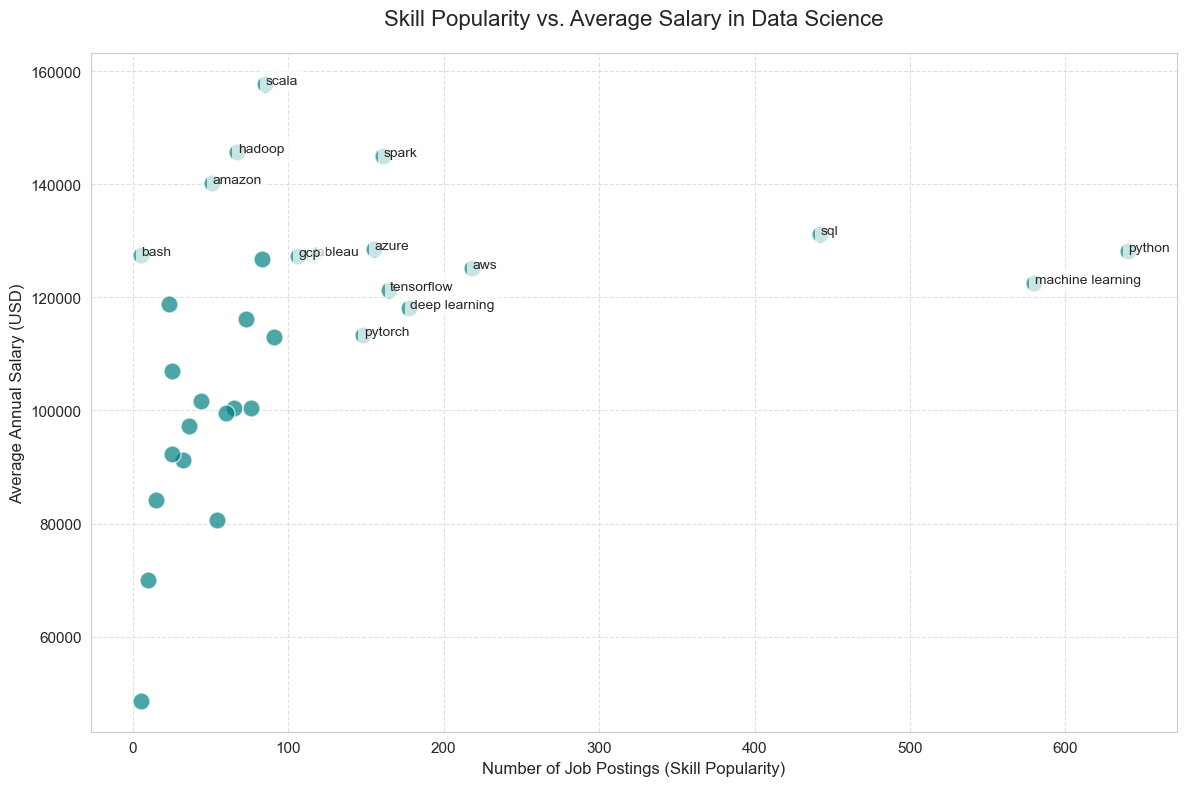

In [31]:
# 1: Calculate skill frequency and average salary
# Using the cleaned skills_exploded DataFrame
skill_analysis = skills_exploded.groupby('single_skill').agg(
    avg_salary=('avg_salary', 'mean'),  # Average salary per skill
    count=('single_skill', 'count')     # Number of job postings requiring the skill
).reset_index()

# Filter out skills that appear in very few postings to reduce noise
# Keep only skills that appear in at least 5 job postings
skill_filtered = skill_analysis[skill_analysis['count'] >= 5]

# 2: Create scatter plot
plt.figure(figsize=(12, 8)) # Set figure size

# Plot scatter plot
sns.scatterplot(
    data=skill_filtered,
    x='count', 
    y='avg_salary',
    s=150,           # Marker size
    alpha=0.7,       # Transparency
    color='teal'     # Marker color
)

# 3: Add labels for key skills
# Label only the highest-paying and most frequent skills to avoid clutter
top_high_pay = skill_filtered.nlargest(10, 'avg_salary')
top_frequent = skill_filtered.nlargest(10, 'count')

# Combine and remove duplicates
top_skills = pd.concat([top_high_pay, top_frequent]).drop_duplicates(subset=['single_skill'])

# Add text labels to the plot
for idx, row in top_skills.iterrows():
    plt.text(
        row['count'] + 0.5,   # Offset text slightly on the x-axis
        row['avg_salary'],    # Y-coordinate
        row['single_skill'],  # Skill name
        fontsize=10,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none') # White background box for readability
    )

# 4: Format the plot
plt.title('Skill Popularity vs. Average Salary in Data Science', fontsize=16, pad=20)
plt.xlabel('Number of Job Postings (Skill Popularity)', fontsize=12)
plt.ylabel('Average Annual Salary (USD)', fontsize=12)

# Disable scientific notation on the y-axis
plt.ticklabel_format(style='plain', axis='y')

# Add grid lines for readability
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 4.6 Correlation Between Number of Skills and Average Salary
* **Objective**: Investigate whether broader skill sets correlate with higher compensation, informing skill investment strategies.
* **Analytical Approach**
  * Counted skills listed in each job posting
  * Correlated skill count with salary using statistical methods
  * Controlled for other variables (seniority, location)
  * Analyzed non-linear relationships and diminishing returns

* **Key Insights**
  * **Skill Breadth vs. Depth**: Examines value of specialization vs. versatility
  * **Diminishing Returns**: Identifies optimal number of skills
  * **Complementary Skills**: Reveals valuable skill combinations

* **Business Implications**
  * Guides skill acquisition strategies (specialization vs. generalization)
  * Informs hiring decisions about skill requirements
  * Helps educators design balanced curricula

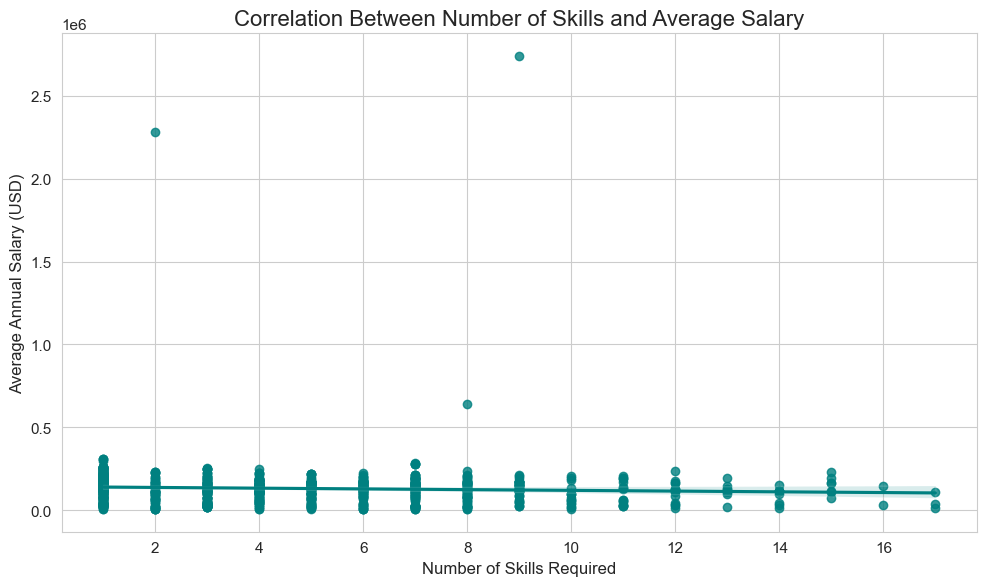

In [27]:
# Calculate the number of skills per job posting
df_clean['num_skills'] = df_clean['skills_clean'].str.split(',').str.len()

plt.figure(figsize=(10, 6))
sns.regplot(x='num_skills', y='avg_salary', data=df_clean, color='teal')
plt.title('Correlation Between Number of Skills and Average Salary', fontsize=16)
plt.xlabel('Number of Skills Required', fontsize=12)
plt.ylabel('Average Annual Salary (USD)', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Strategic Recommendations and Business Applications
* **For Job Seekers: Data-Driven Career Strategy**
  * Foundation First: Master the most common skills for employability
  * Strategic Specialization: Invest in high-paying skills aligned with career goals
  * Experience Planning: Understand salary progression with seniority
  * Skill Portfolio Optimization: Balance breadth and depth based on career stage
  * Market Alignment: Choose skills in high demand and high compensation sectors

* **For Employers: Competitive Talent Strategy**
  * Competitive Compensation: Benchmark salaries against market rates
  * Skill-Based Hiring: Identify skills that correlate with performance
  * Career Development: Create clear progression paths with salary benchmarks
  * Training Investment: Focus on skills with highest ROI for employees

* **For Educators: Relevant Curriculum Design**
  * Market Alignment: Teach skills that are both common and high-paying
  * Progressive Learning: Structure curriculum to support career advancement
  * Realistic Expectations: Provide accurate salary information by skill and level
  * Strategic Focus: Emphasize skills that offer the best career outcomes


* **Limitations and Future Research**
  * Data Scope: Analysis based on 2025 data; market dynamics may change
  * Geographic Focus: Primarily U.S.-centric; global variations exist
  * Industry Specificity: Findings may vary by industry sector
  * Causation vs. Correlation: Relationships identified may have lurking factors
  * Future Directions: Longitudinal analysis, industry segmentation, global comparisons